# Variational KdV on fake hardware

Team: Andrei Poliakov, Kyro Jeremy Gibling, Nadav Carmel, Pak Tik, Sahil Ugale

Optimizes each timestep on the ideal simulator, then reads out the same circuits on a
FakeSherbrooke noise model (qiskit-aer). Reuses the already-optimized parameters -- re-optimizing
against noisy measurements directly is future work.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from qiskit.quantum_info import Statevector

from kdv import ansatz, get_state, get_expval_ideal, kdv_cost
from discretization import periodic_D3, construct_F2_periodic
from fake_hardware import make_fake_backend, noisy_state_fidelity, noisy_decoded_state

CLASSICAL_COLOR = "#52514e"
IDEAL_COLOR = "#2a78d6"
NOISY_COLOR = "#eb6834"


## Setup


In [2]:
n = 2
N = 2 ** n
x = np.linspace(0, 1, N, endpoint=False)
dx = x[1] - x[0]
delta = 0.0625
dt = 0.01
n_steps = 4

u0 = np.array([0.0, -0.5, 1 / np.sqrt(2), 0.5])
u0 = u0 / np.linalg.norm(u0)
nparams = 3

D3 = periodic_D3(N, dx)
F2 = -1 / (2 * dx) * construct_F2_periodic(N)
classical_states = [u0.copy()]
f = u0.copy()
for _ in range(n_steps):
    f = f + dt * (-delta * (D3 @ f) + F2 @ np.kron(f, f))
    classical_states.append(f.copy())
classical_states = np.array(classical_states)


## Ideal optimization


In [3]:
def init_loading(theta, target):
    v = np.real(Statevector(ansatz(theta)).data)
    return np.sum((v - target) ** 2)


best = None
for trial in range(20):
    theta0 = np.random.default_rng(trial).random(nparams) * 2 * np.pi
    res = sp.optimize.minimize(init_loading, theta0, args=(u0,), method="BFGS")
    if best is None or res.fun < best.fun:
        best = res
theta = np.concatenate(([1.0], best.x))

theta_trajectory = [theta.copy()]
for step in range(n_steps):
    def objective(theta_new):
        cost, _ = kdv_cost(theta_new, theta, dt, dx, delta, get_expval_ideal)
        return cost

    best_new = None
    for trial in range(10):
        guess = theta + np.random.default_rng(300 + 10 * step + trial).normal(scale=0.05, size=nparams + 1)
        res = sp.optimize.minimize(objective, guess, method="COBYLA", options={"maxiter": 800})
        if best_new is None or res.fun < best_new.fun:
            best_new = res
    theta = best_new.x
    theta_trajectory.append(theta.copy())
    print(f"step {step+1}/{n_steps}: cost={best_new.fun:.6f}")


step 1/4: cost=-0.983969


step 2/4: cost=-0.968244


step 3/4: cost=-0.953240


step 4/4: cost=-0.939389


## Fake-hardware readout


In [4]:
noise_model, sim, cm = make_fake_backend(n)

ideal_states = [get_state(th) for th in theta_trajectory]
noisy_states = [noisy_decoded_state(ansatz, th, noise_model, sim, cm) for th in theta_trajectory]
fidelities = [noisy_state_fidelity(ansatz, th[1:], noise_model, sim, cm) for th in theta_trajectory]

for i, fid in enumerate(fidelities):
    print(f"t={i*dt:.2f}: fidelity = {fid:.4f}")


t=0.00: fidelity = 0.9923
t=0.01: fidelity = 0.9926
t=0.02: fidelity = 0.9928
t=0.03: fidelity = 0.9930
t=0.04: fidelity = 0.9931


## Results


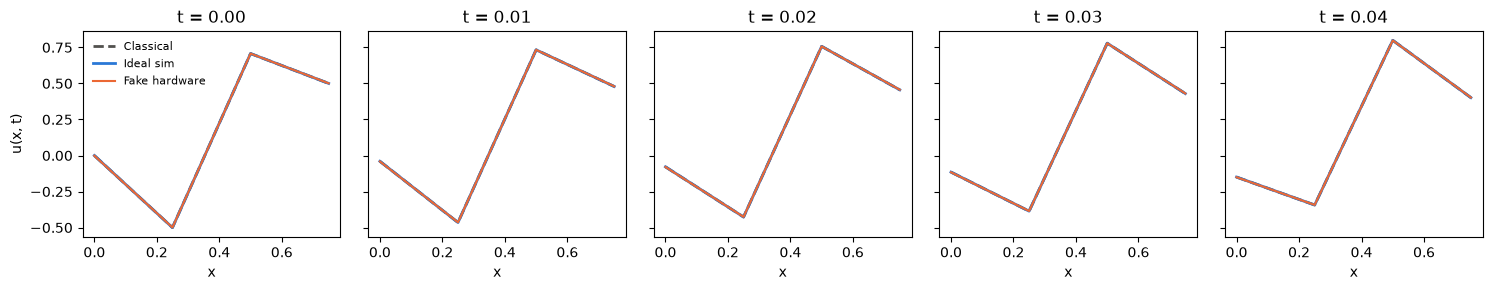

In [5]:
fig, axes = plt.subplots(1, n_steps + 1, figsize=(3.0 * (n_steps + 1), 3.0), sharey=True)
timesteps = np.arange(n_steps + 1) * dt
for i, ax in enumerate(axes):
    ax.plot(x, classical_states[i], "--", color=CLASSICAL_COLOR, lw=2, label="Classical")
    ax.plot(x, ideal_states[i], "-", color=IDEAL_COLOR, lw=2, label="Ideal sim")
    ax.plot(x, noisy_states[i], "-", color=NOISY_COLOR, lw=1.5, label="Fake hardware")
    ax.set_title(f"t = {timesteps[i]:.2f}")
    ax.set_xlabel("x")
axes[0].set_ylabel("u(x, t)")
axes[0].legend(frameon=False, fontsize=8)
fig.tight_layout()


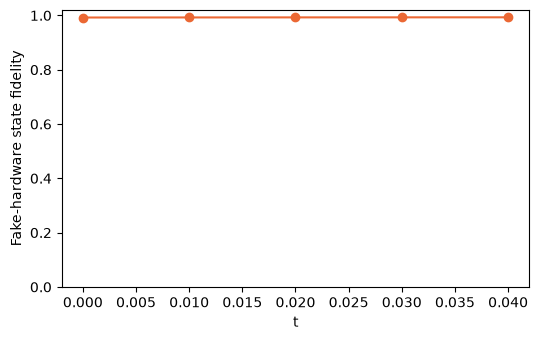

In [6]:
fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.plot(timesteps, fidelities, "o-", color=NOISY_COLOR)
ax.set_xlabel("t")
ax.set_ylabel("Fake-hardware state fidelity")
ax.set_ylim(0, 1.02)
fig.tight_layout()
